# Step J — Effect of 1.5 GW Nuclear on Denmark's Import Reliance and Price Exposure

**Research question:** Does Danish nuclear reduce Denmark's reliance on electricity imports
and its exposure to very high price hours?

**Approach:** Run two scenarios on the Step D interconnected network (DK–DE–SE–NO):
- **Baseline** (`net_d`): Step D as-is — wind, solar, CCGT, batteries, no nuclear
- **+ Nuclear** (`net`): Same network with a fixed 1.5 GW thorium plant added to Denmark

All other settings (neighbours, line capacities, 2015 data) are identical between scenarios.


## Imports

In [1]:
from pathlib import Path
import pypsa
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import importlib
import functions_to_investigate as fti


/Users/kenzomaetanimachholm/Desktop/DTU/Masters - Semester 2/Integrated Energy/Integrated-Energy-Grids-A1G21/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Cost parameters for Denmark generators

Annualised capital and marginal costs for Denmark's extendable generators (wind, solar, CCGT).


In [2]:
data = {
    "capital_cost": [
        1500000/25 + 60000,   # wind:  120,000 $/MW/year
        800000/25  + 14000,   # solar:  46,000 $/MW/year
        700000/25  + 24000,   # CCGT:   52,000 $/MW/year
    ],
    "marginal_cost": [0.0, 0.0, 9.5 * 3.6 / 0.56 + 2.30],  # CCGT ≈ 63.4 $/MWh
}
costs = pd.DataFrame(data, index=["wind_combined", "solar", "CCGT"])
print(costs.round(2))


               capital_cost  marginal_cost
wind_combined      120000.0           0.00
solar               46000.0           0.00
CCGT                52000.0          63.37


## D1 — Load hourly demand for all four countries

In [3]:
# -- CELL D1 ----------------------------------------------------
# Load hourly demand data for all four countries used in Step D

# Resolve project root robustly (works whether cwd is project root or subfolder)
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "STEP D - electricity_demand.csv").exists():
    PROJECT_DIR = PROJECT_DIR.parent

demand_path = PROJECT_DIR / "STEP D - electricity_demand.csv"
if not demand_path.exists():
    raise FileNotFoundError(f"Could not find demand file at: {demand_path}")

demand_all = pd.read_csv(
    demand_path,
    sep=";",
    index_col=0,
    parse_dates=True
)

# Keep only 2015 rows and the four countries we need
# Convert to timezone-naive (PyPSA requirement)
demand_all.index = pd.to_datetime(demand_all.index, utc=True).tz_localize(None)
demand_all = demand_all.sort_index()
demand_2015 = demand_all[demand_all.index.year == 2015].copy()

# Column names in the CSV use 3-letter country codes
demand_dk = demand_2015["DNK"].astype(float)
demand_de = demand_2015["DEU"].astype(float)
demand_se = demand_2015["SWE"].astype(float)
demand_no = demand_2015["NOR"].astype(float)

print("Demand shapes (should all be 8760 rows):")
print(f"  DK: {demand_dk.shape},  DE: {demand_de.shape},  SE: {demand_se.shape},  NO: {demand_no.shape}")

assert len(demand_dk) == 8760, "Denmark demand is not 8760 hours."
assert len(demand_de) == 8760, "Germany demand is not 8760 hours."
assert len(demand_se) == 8760, "Sweden demand is not 8760 hours."
assert len(demand_no) == 8760, "Norway demand is not 8760 hours."

print("\nAnnual demand [TWh]:")
print(f"  Denmark: {demand_dk.sum()/1e6:.2f}")
print(f"  Germany: {demand_de.sum()/1e6:.2f}")
print(f"  Sweden:  {demand_se.sum()/1e6:.2f}")
print(f"  Norway:  {demand_no.sum()/1e6:.2f}")


Demand shapes (should all be 8760 rows):
  DK: (8760,),  DE: (8760,),  SE: (8760,),  NO: (8760,)

Annual demand [TWh]:
  Denmark: 32.81
  Germany: 505.26
  Sweden:  135.93
  Norway:  128.65


## D1.5 — Load capacity factor data for neighbouring countries

From the Energy Charts time series (2015, hourly). Germany is downsampled from 15-min to
hourly by averaging.


In [4]:
# Cell 1.5
# Make this cell runnable on its own
if "PROJECT_DIR" not in globals():
    PROJECT_DIR = Path.cwd()
    if not (PROJECT_DIR / "STEP D - electricity_demand.csv").exists():
        PROJECT_DIR = PROJECT_DIR.parent

cf_base = PROJECT_DIR / "Other country data" / "Energy charts data"

# --------------------------------------------------
# 1. Read snapshot reference from Denmark / Step A
# --------------------------------------------------
dataframe_dk = pd.read_csv(PROJECT_DIR / "DK_2015_merged.csv", index_col=0, parse_dates=True)
snapshots = pd.DatetimeIndex(dataframe_dk.index)

# Optional but often useful:
snapshots = snapshots.tz_localize(None)

# --------------------------------------------------
# 2. Germany: read + convert 15-min to hourly
# --------------------------------------------------
cf_de_raw = pd.read_csv(cf_base / "Germany" / "Germany_hourly_capacity_factors.csv")
cf_de_raw["timestamp"] = pd.to_datetime(cf_de_raw["timestamp"])
cf_de_raw = cf_de_raw.set_index("timestamp").sort_index()
cf_de_raw.index = cf_de_raw.index.tz_localize(None)

# Convert 15-min to hourly by averaging
cf_de = cf_de_raw.resample("h").mean()

# Keep only the technologies you need
cf_de["wind_combined"] = cf_de["Wind onshore"]   # for now; add offshore separately only if you model it
cf_de["solar"] = cf_de["Solar AC"]
cf_de["CCGT"] = cf_de["Fossil gas"]
cf_de["nuclear"] = cf_de["Nuclear"]

# If you keep coal fixed without p_max_pu, no need for coal profile
cf_de = cf_de[["wind_combined", "solar", "CCGT", "nuclear"]]

# Align exactly to model snapshots
cf_de = cf_de.reindex(snapshots)

# --------------------------------------------------
# 3. Sweden: read hourly data
# --------------------------------------------------
cf_se = pd.read_csv(cf_base / "Sweden" / "Sweden_hourly_capacity_factors.csv")
cf_se["timestamp"] = pd.to_datetime(cf_se["timestamp"])
cf_se = cf_se.set_index("timestamp").sort_index()
cf_se.index = cf_se.index.tz_localize(None)

cf_se["wind_combined"] = cf_se["Wind onshore"]
cf_se["nuclear"] = cf_se["Nuclear"]
cf_se["hydro"] = cf_se["Hydro water reservoir"]

cf_se = cf_se[["wind_combined", "nuclear", "hydro"]]
cf_se = cf_se.reindex(snapshots)
cf_se = cf_se.bfill()

# --------------------------------------------------
# 4. Norway: read hourly data
# --------------------------------------------------
cf_no = pd.read_csv(cf_base / "Norway" / "Norway_hourly_capacity_factors.csv")
cf_no["timestamp"] = pd.to_datetime(cf_no["timestamp"])
cf_no = cf_no.set_index("timestamp").sort_index()
cf_no.index = cf_no.index.tz_localize(None)

cf_no["wind_combined"] = cf_no["Wind onshore"]
cf_no["hydro"] = cf_no["Hydro water reservoir"]
cf_no["CCGT"] = cf_no["Fossil gas"]   # only if you later choose to model Norwegian gas

cf_no = cf_no[["wind_combined", "hydro"]]
cf_no = cf_no.reindex(snapshots)

# --------------------------------------------------
# 5. Basic checks — leaving them as is for now.
# --------------------------------------------------
print("Germany shape:", cf_de.shape)
print("Sweden shape:", cf_se.shape)
print("Norway shape:", cf_no.shape)

print("\nMissing values:")
print("Germany\n", cf_de.isna().sum())
print("Sweden\n", cf_se.isna().sum())
print("Norway\n", cf_no.isna().sum())


Germany shape: (8760, 4)
Sweden shape: (8760, 3)
Norway shape: (8760, 2)

Missing values:
Germany
 wind_combined    1
solar            1
CCGT             1
nuclear          1
dtype: int64
Sweden
 wind_combined    1
nuclear          1
hydro            1
dtype: int64
Norway
 wind_combined    74
hydro             2
dtype: int64


## D2 — Build the network: 4 buses, snapshots, Denmark CFs

In [5]:
# ── CELL D2 ─────────────────────────────────────────────────
# Build the network: 4 buses, aligned snapshots, and country-level demand

# Re-load 2015 Danish wind/solar capacity factors
dataframe_dk = pd.read_csv("DK_2015_merged.csv", index_col=0, sep=",", parse_dates=True)
# Convert to timezone-naive (PyPSA requirement)
dataframe_dk.index = pd.to_datetime(dataframe_dk.index, utc=True).tz_localize(None)
dataframe_dk = dataframe_dk.sort_index()

CF_wind = dataframe_dk["wind_cf_Unnamed: 1"].astype(float)
CF_solar = dataframe_dk["pv_cf_Unnamed: 1"].astype(float)

# Use the Danish CF index as the master snapshot index
snapshots = dataframe_dk.index

# Align all Step D demand series to the exact same hourly index
demand_dk = demand_dk.reindex(snapshots)
demand_de = demand_de.reindex(snapshots)
demand_se = demand_se.reindex(snapshots)
demand_no = demand_no.reindex(snapshots)

assert demand_dk.notna().all(), "Denmark demand has missing values after alignment."
assert demand_de.notna().all(), "Germany demand has missing values after alignment."
assert demand_se.notna().all(), "Sweden demand has missing values after alignment."
assert demand_no.notna().all(), "Norway demand has missing values after alignment."
assert CF_wind.notna().all(), "Wind capacity factor has missing values."
assert CF_solar.notna().all(), "Solar capacity factor has missing values."

# ---- Create the network ----
net = pypsa.Network()
net.set_snapshots(snapshots)

# ---- Add 4 buses (one per country) ----
buses = {
    "Denmark": (10.0, 56.0),
    "Germany": (10.5, 51.5),
    "Sweden":  (15.0, 59.5),
    "Norway":  (10.0, 62.0),
}
for name, (x, y) in buses.items():
    net.add("Bus", name, x=x, y=y)

print("Buses added:", list(net.buses.index))
print(f"Snapshots set: {len(net.snapshots)} hours")


Buses added: ['Denmark', 'Germany', 'Sweden', 'Norway']
Snapshots set: 8760 hours


## D3 — Loads (one per country)

In [6]:
# ── CELL D3 ─────────────────────────────────────────────────
# Add electricity demand (Load) for each country

net.add("Load", "load_DK", bus="Denmark", p_set=demand_dk.values)
net.add("Load", "load_DE", bus="Germany", p_set=demand_de.values)
net.add("Load", "load_SE", bus="Sweden", p_set=demand_se.values)
net.add("Load", "load_NO", bus="Norway", p_set=demand_no.values)

print("Total annual demand [TWh]:")
print(f"  Denmark: {demand_dk.sum()/1e6:.2f}")
print(f"  Germany: {demand_de.sum()/1e6:.2f}")
print(f"  Sweden:  {demand_se.sum()/1e6:.2f}")
print(f"  Norway:  {demand_no.sum()/1e6:.2f}")


Total annual demand [TWh]:
  Denmark: 32.81
  Germany: 505.26
  Sweden:  135.93
  Norway:  128.65


## D4 — Carriers

In [7]:
# ── CELL D4 ─────────────────────────────────────────────────
# Add carriers used in the reduced Step D system

net.add("Carrier", ["wind_onshore", "solar", "CCGT",
                    "hydro", "nuclear", "coal", "battery"],
        color=["blue", "yellow", "brown", "cyan", "purple", "grey", "purple"])


print("Carriers added:")
print(list(net.carriers.index))


Carriers added:
['wind_onshore', 'solar', 'CCGT', 'hydro', 'nuclear', 'coal', 'battery']


## D5 — Denmark generators (extendable)

In [8]:
# ── CELL D5 ─────────────────────────────────────────────────
# DENMARK – extendable generators (same logic as Step A)

net.add(
    "Generator", "DK_wind",
    bus="Denmark",
    carrier="wind_combined",
    capital_cost=costs.loc["wind_combined", "capital_cost"],
    marginal_cost=costs.loc["wind_combined", "marginal_cost"],
    p_max_pu=CF_wind.values,
    p_nom_extendable=True
)

net.add(
    "Generator", "DK_solar",
    bus="Denmark",
    carrier="solar",
    capital_cost=costs.loc["solar", "capital_cost"],
    marginal_cost=costs.loc["solar", "marginal_cost"],
    p_max_pu=CF_solar.values,
    p_nom_extendable=True
)

net.add(
    "Generator", "DK_CCGT",
    bus="Denmark",
    carrier="CCGT",
    capital_cost=costs.loc["CCGT", "capital_cost"],
    marginal_cost=costs.loc["CCGT", "marginal_cost"],
    efficiency=0.58,
    p_nom_extendable=True
)

print("Denmark generators added (extendable).")
print(net.generators.loc[["DK_wind", "DK_solar", "DK_CCGT"], ["bus", "carrier", "p_nom_extendable"]])


Denmark generators added (extendable).
               bus        carrier  p_nom_extendable
Generator                                          
DK_wind    Denmark  wind_combined              True
DK_solar   Denmark          solar              True
DK_CCGT    Denmark           CCGT              True


## D5b — Denmark nuclear generator (extendable)

Adding a thorium-based nuclear option for Denmark using the parameters from `table.xlsx`
(500 MW(e) reference plant).

| Parameter | Value | Source |
|---|---|---|
| CAPEX | \$2,980/kW = \$2,980,000/MW | table.xlsx |
| Fixed O&M (OPEX) | \$48M/500MW = \$96,000/MW/year | table.xlsx |
| Fuel cost | \$2.22/MWh(th) | table.xlsx |
| Assumed lifetime | 40 years | standard nuclear assumption |
| Assumed thermal efficiency | 33 % | standard nuclear |

Derived PyPSA parameters:
- `capital_cost` = CAPEX/lifetime + fixed O&M = 2,980,000/40 + 96,000 = **\$170,500/MW/year**
- `marginal_cost` = fuel cost per MWh(th) / η = 2.22 / 0.33 ≈ **\$6.73/MWh(e)**
- `p_max_pu = 1.0` (nuclear is dispatchable baseload; no time-varying CF)

In [9]:
nuclear_capex_per_mw  = 2_980_000   # $/MW
nuclear_fixed_om      =    96_000   # $/MW/year
nuclear_lifetime      =        40   # years
nuclear_fuel_cost_th  =      2.22   # $/MWh(th)
nuclear_efficiency    =      0.33   # thermal → electrical

nuclear_capital_cost  = nuclear_capex_per_mw / nuclear_lifetime + nuclear_fixed_om
nuclear_marginal_cost = nuclear_fuel_cost_th / nuclear_efficiency

print(f"Nuclear: capital {nuclear_capital_cost:,.0f} $/MW/yr  |  marginal {nuclear_marginal_cost:.2f} $/MWh(e)")

net.add("Generator", "DK_nuclear",
        bus="Denmark", carrier="nuclear",
        capital_cost=nuclear_capital_cost, marginal_cost=nuclear_marginal_cost,
        p_max_pu=1.0, p_nom=1500, p_nom_extendable=False)


Nuclear: capital 170,500 $/MW/yr  |  marginal 6.73 $/MWh(e)


Index(['DK_nuclear'], dtype='object')

## D6 — Neighbouring-country generators (fixed capacity)

Capacities reflect 2015 ENTSO-E / IEA values. Marginal costs are approximate SRMC figures.


In [10]:
# -- CELL D6 ----------------------------------------------------
# NEIGHBOURING COUNTRIES - fixed-capacity generators

# For all installed capacities the values are taken from ENTSO-E data.

# ---- Germany ----
net.add("Generator", "DE_wind", bus="Germany", carrier="wind_combined",
        p_nom=41300, 
        marginal_cost=0,
        p_max_pu=cf_de["wind_combined"].values,
        p_nom_extendable=False)

net.add("Generator", "DE_solar", bus="Germany", carrier="solar",
        p_nom=37000,
        marginal_cost=0,
        p_max_pu=cf_de["solar"].values,
        p_nom_extendable=False)

net.add("Generator", "DE_CCGT", bus="Germany", carrier="CCGT",
        p_nom=28360,
        marginal_cost=62.0, # Gas price: 0.032 €/kWh_th = 32 €/MWh_th at 56% efficiency: 32 / 0.56 = 57.14 €/MWh_el. FX (1.09): ≈ 62.3 $/MWh_el
        p_nom_extendable=False)

net.add("Generator", "DE_nuclear",
        bus="Germany",
        carrier="nuclear",
        p_nom=10800,
        marginal_cost=11.0, # Nuclear SRMC ≈ 10 €/MWh_el → ≈ 11 $/MWh_el (fuel + O&M)
        p_nom_extendable=False)

# 2015 German coal fleet (removing it would tighten supply)
net.add(
    "Generator", "DE_coal",
    bus="Germany",
    carrier="coal",
    p_nom=21420,
    marginal_cost=40.0, # Coal SRMC ≈ 40 €/MWh → ≈ 44 $/MWh (fuel + CO2 + variable O&M, ~40% efficiency)
    p_nom_extendable=False
)

# ---- Sweden ----
net.add("Generator", "SE_hydro", bus="Sweden", carrier="hydro",
        p_nom=15920,
        marginal_cost=5.0, # Hydro SRMC ≈ 0–5 €/MWh_el (no fuel; driven by opportunity cost of water). Assumed 5 $/MWh accounting for some opportunity cost.
        p_max_pu=cf_se["hydro"].values,
        p_nom_extendable=False)

net.add("Generator", "SE_nuclear", bus="Sweden", carrier="nuclear",
        p_nom=8900,
        marginal_cost=11.0, # Nuclear SRMC ≈ 10 €/MWh_el → ≈ 11 $/MWh_el (fuel + O&M)
        p_nom_extendable=False)

net.add("Generator", "SE_wind", bus="Sweden", carrier="wind_combined",
        p_nom=5500,
        marginal_cost=0,
        p_max_pu=cf_se["wind_combined"].values,
        p_nom_extendable=False)

# ---- Norway ----
net.add("Generator", "NO_hydro", bus="Norway", carrier="hydro",
        p_nom=29900,
        marginal_cost=5.0, # Hydro SRMC ≈ 0–5 €/MWh_el (no fuel; driven by opportunity cost of water). Assumed 5 $/MWh accounting for some opportunity cost.
        p_max_pu=cf_no["hydro"].values,
        p_nom_extendable=False)

net.add("Generator", "NO_wind", bus="Norway", carrier="wind_combined",
        p_nom=700,
        marginal_cost=0,
        p_max_pu=cf_no["wind_combined"].values,
        p_nom_extendable=False)


print("Neighbouring country generators added (fixed capacity).")
print(net.generators[["bus", "carrier", "p_nom", "p_nom_extendable"]].to_string())


Neighbouring country generators added (fixed capacity).
                bus        carrier    p_nom  p_nom_extendable
Generator                                                    
DK_wind     Denmark  wind_combined      0.0              True
DK_solar    Denmark          solar      0.0              True
DK_CCGT     Denmark           CCGT      0.0              True
DK_nuclear  Denmark        nuclear   1500.0             False
DE_wind     Germany  wind_combined  41300.0             False
DE_solar    Germany          solar  37000.0             False
DE_CCGT     Germany           CCGT  28360.0             False
DE_nuclear  Germany        nuclear  10800.0             False
DE_coal     Germany           coal  21420.0             False
SE_hydro     Sweden          hydro  15920.0             False
SE_nuclear   Sweden        nuclear   8900.0             False
SE_wind      Sweden  wind_combined   5500.0             False
NO_hydro     Norway          hydro  29900.0             False
NO_wind      N

## D7 — HVAC transmission lines (DC approximation)

Five lines between the four countries creating two closed loops. All lines have
reactance `x = 0.1 pu`, nominal voltage 380 kV (the DTU convention for "400 kV" HVAC).


In [11]:
# ── CELL D7 ─────────────────────────────────────────────────
# Add HVAC transmission lines for the DC approximation

# First, add voltage level to buses (required by PyPSA)
for bus in net.buses.index:
    net.buses.loc[bus, "v_nom"] = 380  # 380 kV AC transmission

lines = [
    ("line_DK_DE", "Denmark", "Germany", 2380, 350), # Aggregated transmission lines
    ("line_DK_SE", "Denmark", "Sweden", 2000, 180), # Konti-Skan and Øresund
    ("line_DK_NO", "Denmark", "Norway", 1680, 300), # Skagerrak HVDC system
    ("line_SE_NO", "Sweden", "Norway", 2100, 500), # NO1 -SE3
    ("line_DE_SE", "Germany", "Sweden", 600, 700), # Baltic Cable
]

for name, bus0, bus1, transfer_capacity_mw, length_km in lines:
    net.add(
        "Line",
        name,
        bus0=bus0,
        bus1=bus1,
        s_nom=transfer_capacity_mw,  # actual line limit used by PyPSA
        x=0.1,
        r=0.01,
        length=length_km,
        p_nom=transfer_capacity_mw   # helper field kept for existing plots/functions
    )

print("Transmission lines added:")
print(net.lines[["bus0", "bus1", "s_nom", "x", "r", "length"]].to_string())


Transmission lines added:
               bus0     bus1   s_nom    x     r  length
Line                                                   
line_DK_DE  Denmark  Germany  2380.0  0.1  0.01   350.0
line_DK_SE  Denmark   Sweden  2000.0  0.1  0.01   180.0
line_DK_NO  Denmark   Norway  1680.0  0.1  0.01   300.0
line_SE_NO   Sweden   Norway  2100.0  0.1  0.01   500.0
line_DE_SE  Germany   Sweden   600.0  0.1  0.01   700.0


## D8 — Batteries + optimise both scenarios

Adds battery storage to all four buses, then runs two Gurobi solves:
1. **`net_d`** — copy of the network with `DK_nuclear` removed (Step D baseline)
2. **`net`** — full Step J network with 1.5 GW nuclear


In [12]:
# ── CELL D8 ─────────────────────────────────────────────────
battery_investment_power  = 100_000   # $/MW
battery_investment_energy = 150_000   # $/MWh
battery_fom               =  12_500   # $/MW/year
battery_lifetime          =      20   # years
battery_max_hours         =       4   # h
battery_efficiency        =    0.90   # round-trip

battery_capital_cost_2024 = (
    battery_investment_power  / battery_lifetime
    + battery_fom
    + (battery_investment_energy / battery_lifetime) * battery_max_hours
)
print(f"Battery capital cost: {battery_capital_cost_2024:,.0f} $/MW/year")

for country, bus in [("DK", "Denmark"), ("DE", "Germany"), ("SE", "Sweden"), ("NO", "Norway")]:
    net.add(
        "StorageUnit", f"{country}_battery",
        bus=bus, carrier="battery",
        capital_cost=battery_capital_cost_2024, marginal_cost=0,
        efficiency_store=battery_efficiency**0.5,
        efficiency_dispatch=battery_efficiency**0.5,
        max_hours=battery_max_hours,
        cyclic_state_of_charge=True,
        p_nom_extendable=True,
    )

# ── Scenario 1: Baseline — no nuclear (Step D equivalent) ────
print("\nOptimising baseline (no nuclear)...")
net_d = net.copy()
net_d.remove("Generator", "DK_nuclear")
status_d = net_d.optimize(solver_name="gurobi", solver_options={"output_flag": False})
print(f"  Status: {status_d[0]} | Cost: {net_d.objective/1e9:.3f} B$/yr")

# ── Scenario 2: Step J — with 500 MW nuclear ─────────────────
print("\nOptimising Step J (with nuclear)...")
status = net.optimize(solver_name="gurobi", solver_options={"output_flag": False})
print(f"  Status: {status[0]} | Cost: {net.objective/1e9:.3f} B$/yr")

print("\nDone — net_d = baseline, net = nuclear scenario.")


Battery capital cost: 47,500 $/MW/year

Optimising baseline (no nuclear)...


Index(['DK_wind', 'DE_wind', 'SE_wind', 'NO_wind'], dtype='object', name='Generator')
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[ns]', name='snapshot', freq=None)
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[ns]', name='snapshot', freq=None)
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[ns]', name='snapshot', freq=None)
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[ns]', name='snapshot', freq=None)
DatetimeIndex(['2015-10-25 01:00:00', '2015-12-31 23:00:00'], dtype='datetime64[ns]', name='snapshot', freq=None)
DatetimeIndex(['2015-08-06 22:00:00', '2015-08-06 23:00:00',
               '2015-08-07 00:00:00', '2015-08-07 01:00:00',
               '2015-08-07 02:00:00', '2015-08-07 03:00:00',
               '2015-08-07 04:00:00', '2015-08-07 05:00:00',
               '2015-08-07 06:00:00', '2015-08-07 07:00:00',
               '2015-08-07 08:00:00', '2015-08-07 09:00:00',
               '2015-08-07 10:00:00', '2015-08-07 11:00:00',
         

Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2706870


...

Reading time = 0.60 seconds


INFO:gurobipy:Reading time = 0.60 seconds


obj: 630727 rows, 271567 columns, 1143151 nonzeros


INFO:gurobipy:obj: 630727 rows, 271567 columns, 1143151 nonzeros
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 271567 primals, 630727 duals
Objective: 2.29e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


  Status: ok | Cost: 22.920 B$/yr

Done — net_d = baseline, net = nuclear scenario.


## D9 — Denmark optimal capacities (both scenarios)


In [13]:
# ── CELL D9 ─────────────────────────────────────────────────
cols = ["carrier", "p_nom_opt"]

print("Baseline (no nuclear):")
print(net_d.generators[net_d.generators.bus == "Denmark"][cols].to_string())

print("\nStep J (+ 500 MW nuclear):")
dk_j = net.generators[net.generators.bus == "Denmark"].copy()
dk_j["p_nom_opt"] = dk_j.apply(
    lambda r: r["p_nom"] if not r["p_nom_extendable"] else r["p_nom_opt"], axis=1
)
print(dk_j[["carrier", "p_nom_extendable", "p_nom_opt"]].to_string())


Baseline (no nuclear):
                 carrier    p_nom_opt
Generator                            
DK_wind    wind_combined  4443.052399
DK_solar           solar     0.000000
DK_CCGT             CCGT  8804.273754

Step J (+ 500 MW nuclear):
                  carrier  p_nom_extendable    p_nom_opt
Generator                                               
DK_wind     wind_combined              True  1909.449959
DK_solar            solar              True     0.000000
DK_CCGT              CCGT              True  7376.763866
DK_nuclear        nuclear             False  1500.000000


## J1 — Import reliance: hours and volume


In [14]:
# ── CELL J1 — Import reliance: baseline vs nuclear ───────────

def dk_hourly_net_imports(n):
    """Positive = Denmark importing, negative = exporting."""
    dk_lines = n.lines[(n.lines.bus0 == "Denmark") | (n.lines.bus1 == "Denmark")]
    imp = pd.Series(0.0, index=n.snapshots)
    for line in dk_lines.index:
        flow = n.lines_t.p0[line]
        if n.lines.loc[line, "bus0"] == "Denmark":
            imp -= flow
        else:
            imp += flow
    return imp

imports_d = dk_hourly_net_imports(net_d)
imports_j = dk_hourly_net_imports(net)
demand_annual_twh = demand_dk.sum() / 1e6

print(f"{'Metric':<38} {'Baseline':>12} {'+ Nuclear':>12}")
print("-" * 64)

for label, imp in [("Baseline", imports_d), ("Nuclear", imports_j)]:
    pass  # compute below

net_d_twh = imports_d.sum() / 1e6
net_j_twh = imports_j.sum() / 1e6
print(f"{'Annual net imports [TWh]':<38} {net_d_twh:>+12.2f} {net_j_twh:>+12.2f}")
print(f"{'  as % of demand':<38} {net_d_twh/demand_annual_twh*100:>+11.1f}% {net_j_twh/demand_annual_twh*100:>+11.1f}%")

h_d = (imports_d > 0).sum()
h_j = (imports_j > 0).sum()
print(f"{'Hours with net imports':<38} {h_d:>10} h  {h_j:>10} h")
print(f"{'  % of year':<38} {h_d/8760:>11.1%} {h_j/8760:>11.1%}")

print(f"{'Peak import [MW]':<38} {imports_d.max():>12.0f} {imports_j.max():>12.0f}")
print(f"{'Peak export [MW]':<38} {imports_d.min():>12.0f} {imports_j.min():>12.0f}")


Metric                                     Baseline    + Nuclear
----------------------------------------------------------------
Annual net imports [TWh]                     +16.66       +12.30
  as % of demand                             +50.8%       +37.5%
Hours with net imports                       8188 h        8392 h
  % of year                                  93.5%       95.8%
Peak import [MW]                               5080         3704
Peak export [MW]                              -5080        -5080


## J2 — Price exposure: high-price hours


In [15]:
# ── CELL J2 — Price exposure: baseline vs nuclear ─────────────
price_d = net_d.buses_t.marginal_price["Denmark"]
price_j = net.buses_t.marginal_price["Denmark"]

print(f"{'Metric':<35} {'Baseline':>12} {'+ Nuclear':>12}")
print("-" * 61)
print(f"{'Mean price [$/MWh]':<35} {price_d.mean():>12.2f} {price_j.mean():>12.2f}")
print(f"{'Median price [$/MWh]':<35} {price_d.median():>12.2f} {price_j.median():>12.2f}")
print(f"{'95th percentile [$/MWh]':<35} {price_d.quantile(0.95):>12.2f} {price_j.quantile(0.95):>12.2f}")
print(f"{'Max price [$/MWh]':<35} {price_d.max():>12.2f} {price_j.max():>12.2f}")
print()
for thresh in [50, 100, 150]:
    h_d = (price_d > thresh).sum()
    h_j = (price_j > thresh).sum()
    print(f"{'Hours > $'+str(thresh)+'/MWh':<35} {h_d:>9} h   {h_j:>9} h")
    print(f"{'  % of year':<35} {h_d/8760:>11.1%} {h_j/8760:>11.1%}")


Metric                                  Baseline    + Nuclear
-------------------------------------------------------------
Mean price [$/MWh]                         42.88        41.88
Median price [$/MWh]                       32.46        32.46
95th percentile [$/MWh]                    63.37        59.88
Max price [$/MWh]                        4188.01      4190.30

Hours > $50/MWh                           792 h         562 h
  % of year                                9.0%        6.4%
Hours > $100/MWh                           14 h          16 h
  % of year                                0.2%        0.2%
Hours > $150/MWh                           14 h          16 h
  % of year                                0.2%        0.2%


## J3 — Side-by-side comparison chart


In [ ]:
# ── CELL J3 — Side-by-side comparison chart ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hours = np.arange(1, len(net.snapshots) + 1)

# ── Left: Import duration curve ───────────────────────────────
ax = axes[0]
sorted_d = imports_d.sort_values(ascending=False).values / 1e3
sorted_j = imports_j.sort_values(ascending=False).values / 1e3

ax.plot(hours, sorted_d, label="Baseline (no nuclear)", color="steelblue", lw=1.5)
ax.plot(hours, sorted_j, label="+ Nuclear (1.5 GW)",    color="tomato",    lw=1.5, ls="--")
ax.fill_between(hours, sorted_d, 0, where=sorted_d > 0, alpha=0.10, color="steelblue")
ax.fill_between(hours, sorted_j, 0, where=sorted_j > 0, alpha=0.10, color="tomato")
ax.axhline(0, color="black", lw=0.8, ls=":")
ax.set_xlabel("Hours per year (sorted)")
ax.set_ylabel("Net import [GW]   (negative = export)")
ax.set_title("Import Duration Curve — Denmark")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

# ── Right: Price duration curve ───────────────────────────────
ax = axes[1]
price_d = net_d.buses_t.marginal_price["Denmark"]
price_j = net.buses_t.marginal_price["Denmark"]

ax.plot(hours, price_d.sort_values(ascending=False).values,
        label="Baseline (no nuclear)", color="steelblue", lw=1.5)
ax.plot(hours, price_j.sort_values(ascending=False).values,
        label="+ Nuclear (1.5 GW)",    color="tomato",    lw=1.5, ls="--")
for thresh, label in [(50, "$50"), (100, "$100")]:
    ax.axhline(thresh, color="grey", lw=0.8, ls=":", alpha=0.7)
    ax.text(8760, thresh + 2, label, color="grey", fontsize=8, va="bottom", ha="right")
ax.set_xlabel("Hours per year (sorted)")
ax.set_ylabel("Marginal price [$/MWh]")
ax.set_title("Price Duration Curve — Denmark")
ax.set_ylim(bottom=0)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.suptitle("Step J — Effect of 1.5 GW Nuclear: Import Reliance & Price Exposure", y=1.02)
plt.tight_layout()
plt.show()


IndentationError: unexpected indent (1361412426.py, line 41)

## D10 — Line flow statistics

In [17]:
# ── CELL D10 ─────────────────────────────────────────────────
print("=== Average absolute line flow (vs capacity) ===")
flows = net.lines_t.p0.abs().mean()
for line in net.lines.index:
    cap = net.lines.loc[line, "s_nom"]
    util = flows[line] / cap * 100
    print(f"  {line}: avg {flows[line]:.0f} MW  |  capacity {cap:.0f} MW  |  utilisation {util:.1f}%")

print("\n=== Peak line flow (vs capacity) ===")
peak_flows = net.lines_t.p0.abs().max()
for line in net.lines.index:
    cap = net.lines.loc[line, "s_nom"]
    util = peak_flows[line] / cap * 100
    print(f"  {line}: peak {peak_flows[line]:.0f} MW  |  capacity {cap:.0f} MW  |  utilisation {util:.1f}%")


=== Average absolute line flow (vs capacity) ===
  line_DK_DE: avg 334 MW  |  capacity 2380 MW  |  utilisation 14.0%
  line_DK_SE: avg 492 MW  |  capacity 2000 MW  |  utilisation 24.6%
  line_DK_NO: avg 1327 MW  |  capacity 1680 MW  |  utilisation 79.0%
  line_SE_NO: avg 1144 MW  |  capacity 2100 MW  |  utilisation 54.5%
  line_DE_SE: avg 599 MW  |  capacity 600 MW  |  utilisation 99.8%

=== Peak line flow (vs capacity) ===
  line_DK_DE: peak 2380 MW  |  capacity 2380 MW  |  utilisation 100.0%
  line_DK_SE: peak 2000 MW  |  capacity 2000 MW  |  utilisation 100.0%
  line_DK_NO: peak 1680 MW  |  capacity 1680 MW  |  utilisation 100.0%
  line_SE_NO: peak 2100 MW  |  capacity 2100 MW  |  utilisation 100.0%
  line_DE_SE: peak 600 MW  |  capacity 600 MW  |  utilisation 100.0%


## D11 — Average electricity prices per country

In [18]:
# ── CELL D11 ─────────────────────────────────────────────────
print("=== Average electricity price per country [$/MWh] ===")
for bus in ["Denmark", "Germany", "Sweden", "Norway"]:
    avg_price = net.buses_t.marginal_price[bus].mean()
    print(f"  {bus}: {avg_price:.2f} $/MWh")


=== Average electricity price per country [$/MWh] ===
  Denmark: 41.88 $/MWh
  Germany: 213.25 $/MWh
  Sweden: 18.15 $/MWh
  Norway: 20.87 $/MWh


## Plots — network flows, dispatch, line utilisation


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


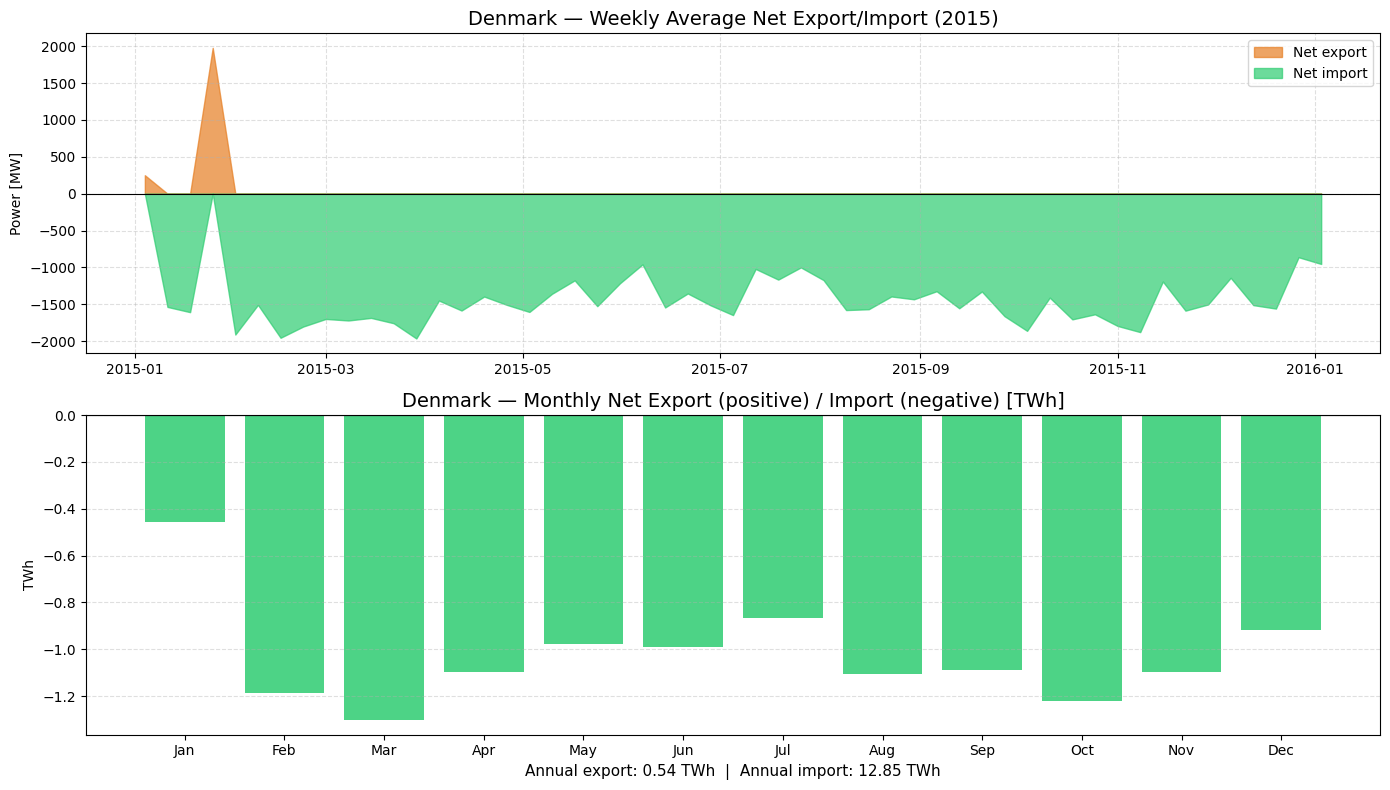

In [19]:
# ── CELL D12 ─────────────────────────────────────────────────
# Net export/import for Denmark over the year
importlib.reload(fti)
fti.plot_network_flows(net)


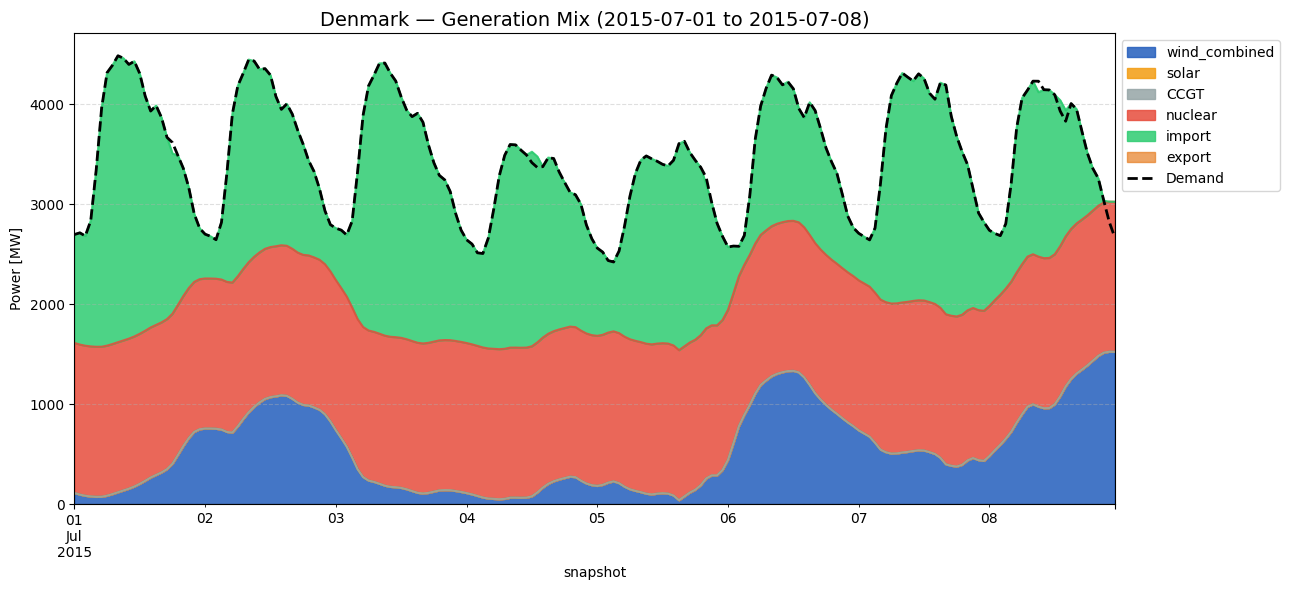

In [20]:
# ── CELL D13 — summer week dispatch for Denmark
fti.plot_generation_mix_network(net, "Denmark", '2015-07-01', '2015-07-08')


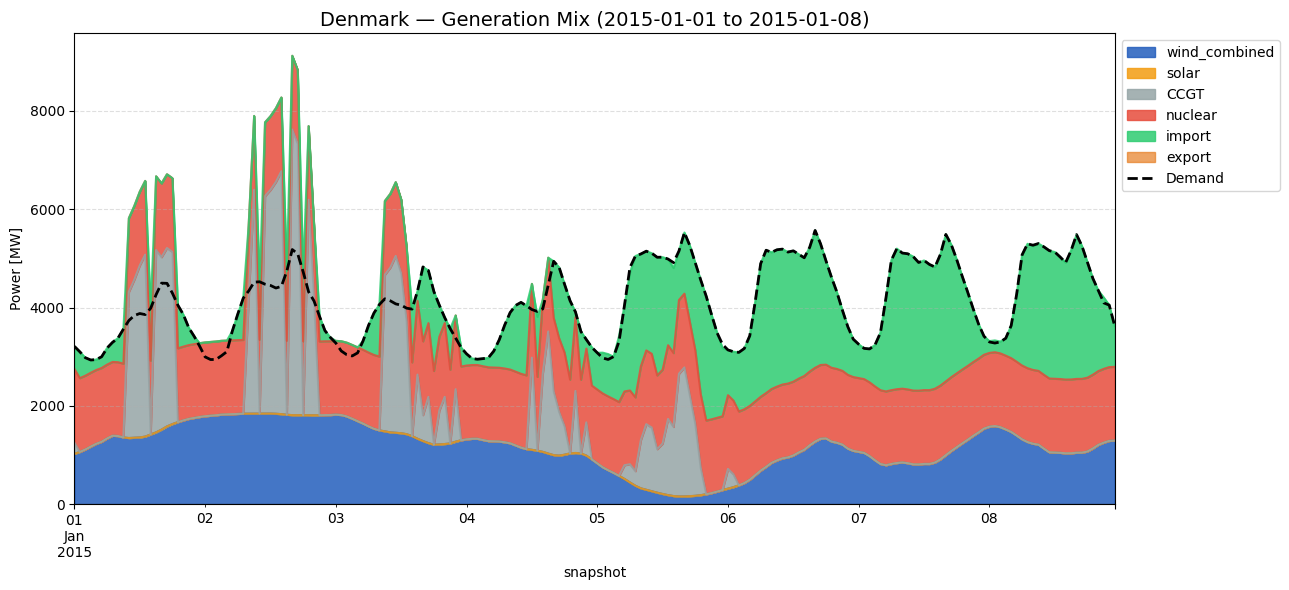

In [21]:
# ── CELL D14 — winter week dispatch for Denmark
fti.plot_generation_mix_network(net, "Denmark", '2015-01-01', '2015-01-08')


## J4 — 24-hour dispatch: winter vs summer, Step D vs Step J


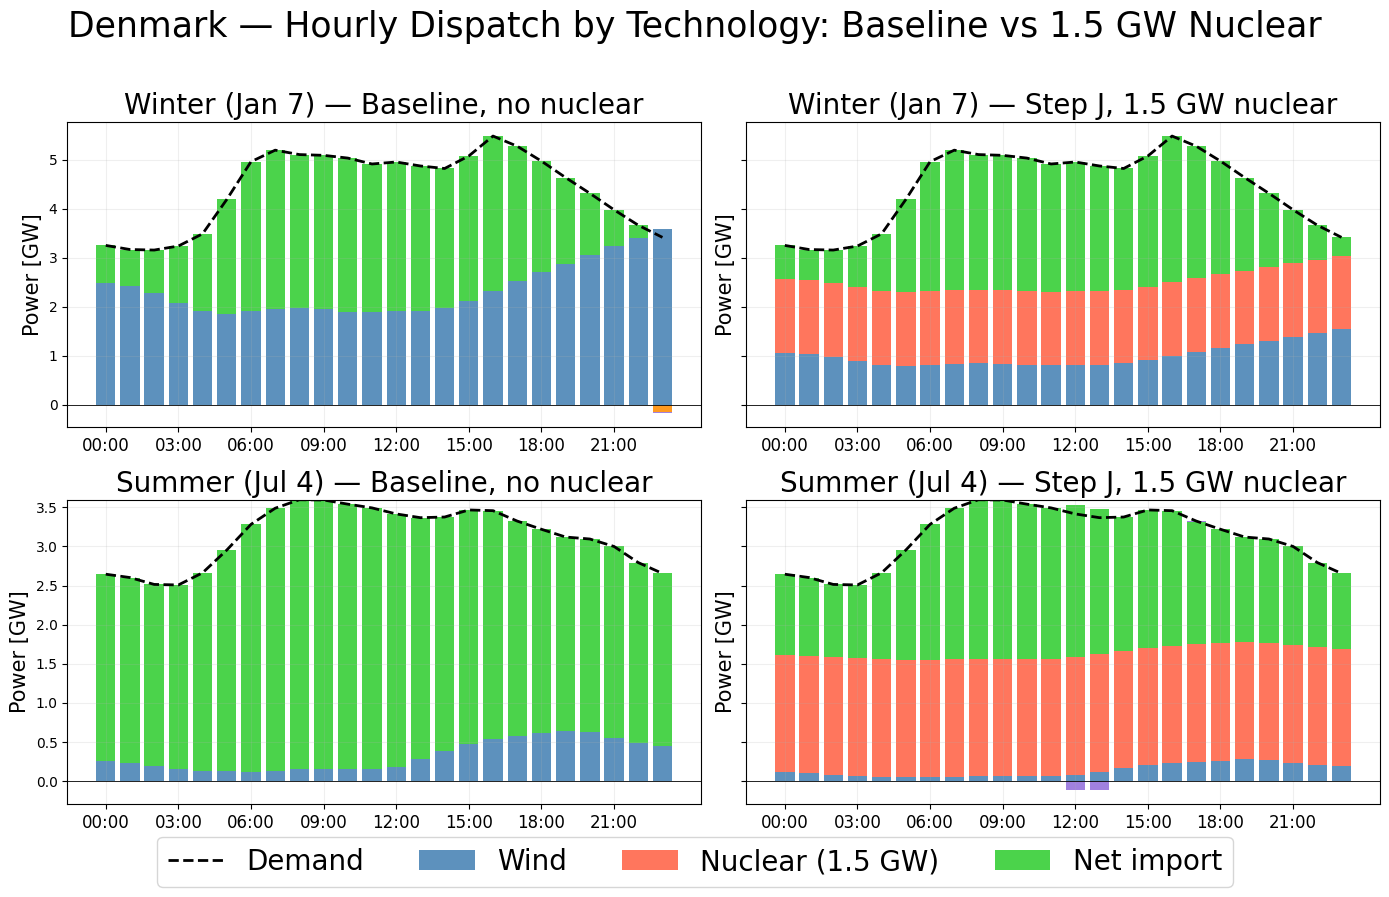

In [40]:
# ── CELL J4 — 24-hour dispatch comparison: winter vs summer ──

STACK = [
    ("DK_wind",    "steelblue",    "Wind"),
    ("DK_solar",   "gold",         "Solar"),
    ("DK_nuclear", "tomato",       "Nuclear (1.5 GW)"),
    ("DK_CCGT",    "saddlebrown",  "CCGT"),
    ("import",     "limegreen",    "Net import"),
    ("export",     "darkorange",   "Net export"),
    ("DK_battery", "mediumpurple", "Battery"),
]

def dk_dispatch_24h(n, day):
    snap = n.snapshots
    t = snap[(snap >= pd.Timestamp(day)) & (snap < pd.Timestamp(day) + pd.Timedelta("24h"))]
    d = {}


    for g in ["DK_wind", "DK_solar", "DK_CCGT", "DK_nuclear"]:
        if g in n.generators_t.p.columns:
            d[g] = n.generators_t.p.loc[t, g].values

    if "DK_battery" in n.storage_units_t.p.columns:
        d["DK_battery"] = n.storage_units_t.p.loc[t, "DK_battery"].values

    dk_lines = n.lines[(n.lines.bus0 == "Denmark") | (n.lines.bus1 == "Denmark")]
    net_imp = np.zeros(len(t))
    for line in dk_lines.index:
        flow = n.lines_t.p0.loc[t, line].values
        net_imp += -flow if n.lines.loc[line, "bus0"] == "Denmark" else flow
    d["import"] = np.maximum(net_imp, 0)
    d["export"] = np.minimum(net_imp, 0)

    demand = n.loads_t.p_set.loc[t, "load_DK"].values if "load_DK" in n.loads_t.p_set.columns \
             else n.loads_t.p.loc[t, "load_DK"].values
    return d, demand


def plot_dispatch(ax, n, day, title):
    d, demand = dk_dispatch_24h(n, day)
    x = np.arange(24)
    bot_pos = np.zeros(24)
    bot_neg = np.zeros(24)
    plotted = []

    for key, color, label in STACK:
        if key not in d:
            continue
        vals = d[key]
        pos = np.maximum(vals, 0)
        neg = np.minimum(vals, 0)
        if pos.any():
            ax.bar(x, pos / 1e3, bottom=bot_pos / 1e3, color=color, label=label, width=0.8, alpha=0.88)
            bot_pos += pos
            plotted.append(label)
        if neg.any():
            ax.bar(x, neg / 1e3, bottom=bot_neg / 1e3, color=color, width=0.8, alpha=0.88)
            bot_neg += neg

    ax.plot(x, demand / 1e3, color="black", lw=2, ls="--", label="Demand", zorder=5)
    ax.axhline(0, color="black", lw=0.6)
    ax.set_title(title, fontsize=20)
    ax.set_xticks(range(0, 24, 3))
    ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 3)], fontsize=12)
    ax.set_ylabel("Power [GW]", fontsize=15)
    ax.grid(True, alpha=0.2)


fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey="row")

plot_dispatch(axes[0, 0], net_d, "2015-01-07", "Winter (Jan 7) — Baseline, no nuclear")
plot_dispatch(axes[0, 1], net,   "2015-01-07", "Winter (Jan 7) — Step J, 1.5 GW nuclear")
plot_dispatch(axes[1, 0], net_d, "2015-07-04", "Summer (Jul 4) — Baseline, no nuclear")
plot_dispatch(axes[1, 1], net,   "2015-07-04", "Summer (Jul 4) — Step J, 1.5 GW nuclear")

# Shared legend from top-right panel (has nuclear in it)
handles, labels = axes[0, 1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=8,
           bbox_to_anchor=(0.5, -0.01), frameon=True, fontsize=20)

# Reduce white space under the suptitle so subplots move up
plt.suptitle("Denmark — Hourly Dispatch by Technology: Baseline vs 1.5 GW Nuclear", fontsize=25, y=0.98)
# Use tight_layout with a rect to reserve space for the legend and title
plt.tight_layout(rect=[0, 0.05, 1, 0.96])

plt.show()


## J5 — Scenario comparison table: capacities, batteries, costs


In [23]:
# ── CELL J5 — Scenario comparison table ──────────────────────

def popt(n, name, comp="generators"):
    df = getattr(n, comp)
    if name not in df.index:
        return 0.0
    r = df.loc[name]
    if comp == "generators":
        return r["p_nom"] if not r["p_nom_extendable"] else r["p_nom_opt"]
    return r["p_nom_opt"]

nuc_fixed_cost = nuclear_capital_cost * 1500 / 1e9   # B$/yr — sunk, not in objective
obj_d  = net_d.objective / 1e9
obj_j  = net.objective   / 1e9
true_j = obj_j + nuc_fixed_cost

sections = {
    "Denmark — generation capacity [GW]": [
        ("Wind",    popt(net_d,"DK_wind")/1e3,    popt(net,"DK_wind")/1e3),
        ("Solar",   popt(net_d,"DK_solar")/1e3,   popt(net,"DK_solar")/1e3),
        ("CCGT",    popt(net_d,"DK_CCGT")/1e3,    popt(net,"DK_CCGT")/1e3),
        ("Nuclear", 0.0,                           popt(net,"DK_nuclear")/1e3),
    ],
    "Battery capacity — all countries [GW]": [
        ("Denmark", popt(net_d,"DK_battery","storage_units")/1e3,
                    popt(net,  "DK_battery","storage_units")/1e3),
        ("Germany", popt(net_d,"DE_battery","storage_units")/1e3,
                    popt(net,  "DE_battery","storage_units")/1e3),
        ("Sweden",  popt(net_d,"SE_battery","storage_units")/1e3,
                    popt(net,  "SE_battery","storage_units")/1e3),
        ("Norway",  popt(net_d,"NO_battery","storage_units")/1e3,
                    popt(net,  "NO_battery","storage_units")/1e3),
    ],
    "System costs [B$/yr]": [
        ("Optimised objective",    obj_d,  obj_j),
        ("Nuclear fixed capital",  0.0,    nuc_fixed_cost),
        ("True total cost",        obj_d,  true_j),
        ("Net saving vs baseline", 0.0,    obj_d - true_j),
    ],
}

# ── Print table ───────────────────────────────────────────────
col_w = 22
print(f"{'Item':<30} {'Baseline':>{col_w}} {'+ Nuclear (1.5 GW)':>{col_w}} {'Change':>{col_w}}")
print("─" * (30 + col_w * 3 + 2))

for section, rows in sections.items():
    print(f"\n  {section}")
    for label, base, nuc in rows:
        chg = nuc - base
        # Format: costs in 3 decimals, capacities in 2 decimals
        is_cost = "B$" in section
        fmt = ".3f" if is_cost else ".2f"
        sign = "+" if chg >= 0 else ""
        print(f"    {label:<26} {base:{col_w-2}{fmt}}  {nuc:{col_w-2}{fmt}}  {sign}{chg:{col_w-3}{fmt}}")

print("\n  Note: 'True total cost' adds nuclear's annualised capital ($170,500/MW/yr × 1,500 MW)")
print(        "        which PyPSA excludes from the objective for fixed-capacity generators.")


Item                                         Baseline     + Nuclear (1.5 GW)                 Change
──────────────────────────────────────────────────────────────────────────────────────────────────

  Denmark — generation capacity [GW]
    Wind                                       4.44                  1.91                -2.53
    Solar                                      0.00                  0.00  +               0.00
    CCGT                                       8.80                  7.38                -1.43
    Nuclear                                    0.00                  1.50  +               1.50

  Battery capacity — all countries [GW]
    Denmark                                    0.01                  0.11  +               0.10
    Germany                                   89.23                 89.18                -0.05
    Sweden                                     3.81                  3.81  +               0.00
    Norway                                    14.06  